###AUTHOR: Saad Abdullah

Importing all required libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import ipywidgets as widgets
from IPython.display import display
import io

Button for Uploadinf the Dataset

In [ ]:
global data
data = None

# Create an upload button
upload_button = widgets.FileUpload(
    accept='.csv',  # Accept only CSV files
    multiple=False  # Do not allow multiple files
)

def handle_upload(change):
    global data
    uploaded_file = list(upload_button.value.values())[0]
    content = uploaded_file['content']
    data = pd.read_csv(io.BytesIO(content))
    print("Dataset uploaded successfully!")

# Link the upload button to the function
upload_button.observe(handle_upload, names='value')

# Display the upload button
display(upload_button)

FileUpload(value={}, accept='.csv', description='Upload')

Dataset uploaded successfully!


#### Understand the shape of dataset and the features it has.

In [ ]:
print("Dimensions of dataset: ", data.shape)
pd.set_option('display.max_columns', data.shape[1] + 1)
data.head()


Dimensions of dataset:  (107, 48)


,ID,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week8_Total,Week1_Stat0,Week1_Stat1,Week1_Stat2,Week1_Stat3,Week2_Stat0,Week2_Stat1,Week2_Stat2,Week2_Stat3,Week3_Stat0,Week3_Stat1,Week3_Stat2,Week3_Stat3,Week4_Stat0,Week4_Stat1,Week4_Stat2,Week4_Stat3,Week5_Stat0,Week5_Stat1,Week5_Stat2,Week5_Stat3,Week6_Stat0,Week6_Stat1,Week6_Stat2,Week6_Stat3,Week7_Stat0,Week7_Stat1,Week7_Stat2,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
0,ML-2020-1,5.00,15.0,5.0,16.09,5.00,21.88,5.0,5.00,5.0,82.97,0,0,0,0,7,30,1,0,30,4,0,0,14,39,2,0,24,6,1,0,28,30,2,0,2,0,1,0,5,4,0,4,8,6,1,0,4
1,ML-2020-2,3.33,15.0,5.0,17.83,5.00,22.27,5.0,4.00,5.0,82.43,8,0,0,0,61,10,3,8,100,4,4,3,130,16,1,4,48,19,5,5,57,22,2,4,31,9,0,8,5,2,0,0,25,3,2,5,4
2,ML-2020-3,1.67,13.0,5.0,15.22,5.00,27.05,2.5,5.00,5.0,79.44,4,0,0,0,19,10,3,3,25,4,0,2,50,19,2,2,28,6,0,2,14,20,2,0,12,4,0,0,8,2,0,0,9,0,1,0,3
3,ML-2020-4,2.50,14.0,5.0,10.00,5.00,31.02,5.0,3.13,5.0,80.65,12,0,0,1,30,10,1,6,79,4,2,2,240,27,2,1,47,4,3,1,99,19,4,0,29,4,5,4,10,0,0,0,7,6,0,0,3
4,ML-2020-6,0.00,15.0,5.0,12.17,4.93,15.91,5.0,4.67,5.0,67.68,6,0,0,0,0,0,0,0,27,5,0,0,6,15,1,0,32,12,0,8,22,18,1,2,43,4,3,6,8,5,1,1,5,3,1,0,2


In [ ]:
data.describe()

,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week8_Total,Week1_Stat0,Week1_Stat1,Week1_Stat2,Week1_Stat3,Week2_Stat0,Week2_Stat1,Week2_Stat2,Week2_Stat3,Week3_Stat0,Week3_Stat1,Week3_Stat2,Week3_Stat3,Week4_Stat0,Week4_Stat1,Week4_Stat2,Week4_Stat3,Week5_Stat0,Week5_Stat1,Week5_Stat2,Week5_Stat3,Week6_Stat0,Week6_Stat1,Week6_Stat2,Week6_Stat3,Week7_Stat0,Week7_Stat1,Week7_Stat2,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.0,107.000000,107.000000,107.00000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,2.406636,7.949626,2.803738,9.237757,2.844673,14.481869,2.383178,2.609439,2.663551,47.380467,6.785047,0.0,0.598131,0.224299,16.88785,13.299065,1.252336,1.841121,31.728972,2.822430,0.953271,1.130841,41.915888,16.046729,1.943925,1.009346,26.074766,5.009346,1.588785,0.663551,37.607477,14.271028,2.775701,0.411215,16.355140,3.242991,1.813084,1.252336,10.514019,3.130841,1.112150,0.355140,7.663551,1.607477,1.093458,0.046729,2.074766
std,2.000317,6.892312,2.493158,8.640610,2.482099,14.080211,2.437501,2.229419,2.414359,41.035589,7.157300,0.0,1.966031,0.730836,16.30796,11.308049,1.505295,4.202761,28.686191,3.206165,2.689544,2.269919,47.164330,17.040675,2.790928,2.806648,31.159269,6.568213,3.954823,1.822003,47.851334,14.009815,7.206271,1.220526,22.242341,5.001587,4.895379,2.399267,15.563846,4.841028,3.658351,1.191577,9.277630,2.687346,3.368928,0.483368,1.993863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,6.50000,10.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,3.330000,12.000000,5.000000,10.870000,5.000000,15.910000,2.500000,3.170000,4.000000,71.530000,4.000000,0.0,0.000000,0.000000,15.00000,11.000000,1.000000,0.000000,27.000000,4.000000,0.000000,0.000000,27.000000,15.000000,1.000000,0.000000,20.000000,4.000000,0.000000,0.000000,18.000000,15.000000,1.000000,0.000000,11.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,3.000000
75%,4.170000,14.305000,5.000000,18.045000,5.000000,27.440000,5.000000,4.710000,5.000000,83.550000,12.000000,0.0,0.000000,0.000000,24.00000,19.000000,1.000000,2.000000,47.500000,4.000000,0.000000,1.000000,74.500000,27.500000,2.000000,1.000000,40.500000,6.500000,1.000000,0.000000,65.000000,25.000000,2.000000,0.000000,27.000000,5.000000,1.000000,2.000000,14.000000,5.000000,0.000000,0.000000,11.000000,2.000000,0.500000,0.000000,4.000000
max,5.000000,15.000000,5.000000,20.000000,5.000000,35.000000,5.000000,5.000000,5.000000,99.710000,27.000000,0.0,11.000000,6.000000,104.00000,57.000000,10.000000,25.000000,108.000000,15.000000,15.000000,14.000000,240.000000,87.000000,13.000000,24.000000,185.000000,39.000000,23.000000,11.000000,208.000000,51.000000,45.000000,7.000000,145.000000,24.000000,

#### There are no missing values in dataset.
My Goal will be to use feature selection in a better way instead of pre processing the whole dataset.

In [ ]:
missing_values = data.isnull().sum()
missing_values

,0
ID,0
Week2_Quiz1,0
Week3_MP1,0
Week3_PR1,0
Week5_MP2,0
Week5_PR2,0
Week7_MP3,0
Week7_PR3,0
Week4_Quiz2,0
Week6_Quiz3,0


#### Glancing at Coorelations
Since there are a lot of features in dataset, so heatmap is not a viable representation of coorelation. I am using a map to show correlation of target variable with other features.

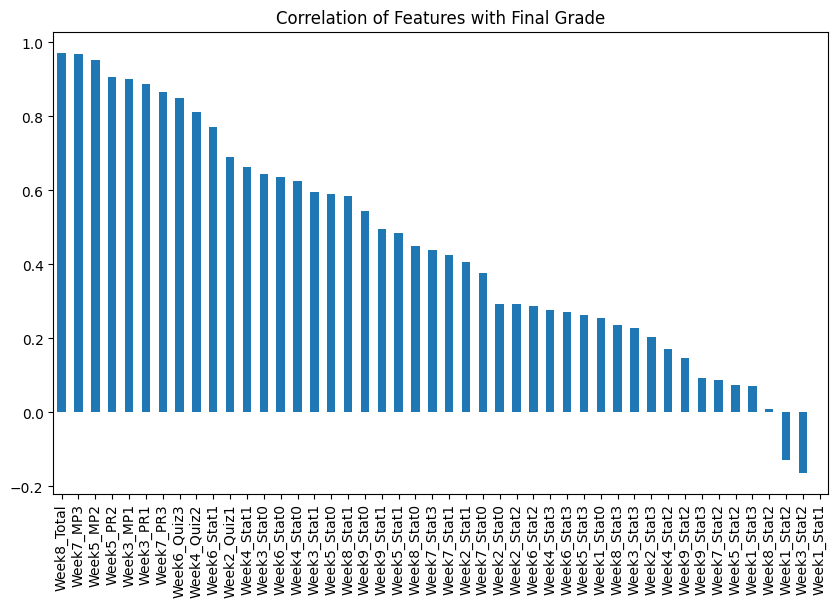

In [ ]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation_with_grade = numeric_data.corr()['Grade'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlation_with_grade.drop('Grade').plot(kind='bar')
plt.title('Correlation of Features with Final Grade')
plt.show()

My focus will be only thoose features who have coorelation greater than 0.5

In [ ]:
correlation_with_grade[correlation_with_grade > 0.5]

,Grade
Grade,1.000000
Week8_Total,0.972348
Week7_MP3,0.968130
Week5_MP2,0.953488
Week5_PR2,0.907837
Week3_MP1,0.901788
Week3_PR1,0.887352
Week7_PR3,0.865616
Week6_Quiz3,0.849920
Week4_Quiz2,0.810920


As can be seen there is class imbalance in dataset, there are no entries for class 1 and class 0 has most of the data. Will keep this in mind while doing training testing split

<ipython-input-11-6ca0278f2b10>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')


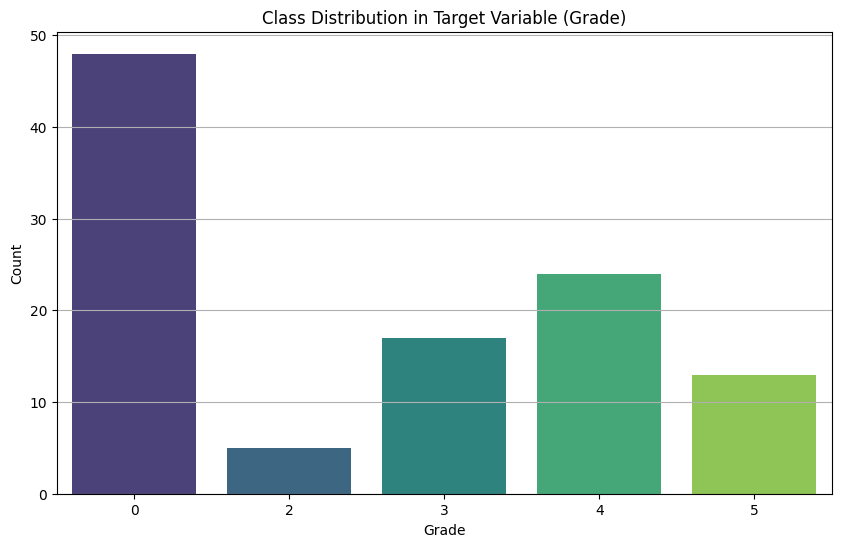

In [ ]:
class_distribution = data['Grade'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Class Distribution in Target Variable (Grade)')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Feature Selection

Out of 48 available features, I selected 15 key features that are closely related to students’ academic performance, including quiz scores, mini-projects, peer reviews and status0 (since i thought the high scoring students maybe thoose who interacted alot with course content). I will train two separate models: one using all 15 features, including ‘Week8_Total’, and another excluding ‘Week8_Total’. This feature is a cumulative score of all activities, which had the highest correlation with the target variable and could introduce bias into the model, hence the second model will exclude it to avoid overfitting.

### Train Test Split
To ensure that both the training and test sets reflected the same distribution of grades, I used stratified splitting instead of a simple random split. StratifiedShuffleSplit maintains the proportion of each grade in the train-test split, improving model generalization and reducing sampling bias.
I tried multiple things for this task, I used recursive feature elimination as well, also tried simple train test split with multiple variations like 80/20, 75/25, 70/30 but all were having issues.

In [ ]:
# Defining features, including 'Week8_Total'
features_with_week8_total = ['Week2_Quiz1', 'Week3_MP1', 'Week3_PR1', 'Week5_MP2', 'Week5_PR2',
                             'Week7_MP3', 'Week7_PR3', 'Week4_Quiz2', 'Week6_Quiz3', 'Week8_Total',
                             'Week3_Stat0', 'Week4_Stat0', 'Week5_Stat0', 'Week6_Stat0', 'Week9_Stat0']

# Defining features without 'Week8_Total'
features_without_week8_total = ['Week2_Quiz1', 'Week3_MP1', 'Week3_PR1', 'Week5_MP2', 'Week5_PR2',
                                'Week7_MP3', 'Week7_PR3', 'Week4_Quiz2', 'Week6_Quiz3',
                                'Week3_Stat0', 'Week4_Stat0', 'Week5_Stat0', 'Week6_Stat0', 'Week9_Stat0']

target = 'Grade'

# Using Stratified Sampling to ensure train/test sets maintain the same class distribution as the full dataset
stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

##### Function Definations, used in KNN.

In [ ]:
# Function to evaluate the knn classification model using cross-validation
def evaluate_classification_model_knn(model, X_train, y_train):
    # Stratified K-fold cross-validation ensures each fold has the same class distribution as the dataset
    stratified_kfold = StratifiedKFold(n_splits=5)

    # Cross-validation: Returns accuracy scores for each fold
    cv_scores = cross_val_score(model, X_train, y_train, cv=stratified_kfold, scoring='accuracy')
    print(f'Cross-Validation Accuracy Scores: {cv_scores}')
    print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}')
    return cv_scores.mean()

# Function for final evaluation (hold out) on the test set
def final_test_evaluation(model, X_test, y_test):
    test_predictions = model.predict(X_test)

    test_accuracy = accuracy_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions, average='macro')  # Precision for each class
    test_recall = recall_score(y_test, test_predictions, average='macro')  # Recall for each class

    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, test_predictions))

    cm = confusion_matrix(y_test, test_predictions, labels=[0, 1, 2, 3, 4, 5])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3, 4, 5], yticklabels=[0, 1, 2, 3, 4, 5])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Function to calculate and visualize feature importance using permutation importance
def calculate_feature_importance(model, X_test, y_test, feature_names):
    # Perform permutation importance: Measures decrease in model performance when a feature's values are randomly shuffled
    perm_importance = permutation_importance(model, X_test, y_test, scoring='accuracy', n_repeats=10, random_state=42)

    # Get the importance scores (mean importance)
    importance_scores = perm_importance.importances_mean

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_scores
    }).sort_values(by='Importance', ascending=False)

    print("Top 3 Most Important Features:")
    print(feature_importance_df.head(3))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title('Feature Importance (Permutation)')
    plt.show()

def plot_decision_boundaries(X, y, model, title):
    # Fit PCA on the dataset to reduce to 2D for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create a mesh grid for plotting decision boundaries
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_points_original = pca.inverse_transform(mesh_points)

    Z = model.predict(mesh_points_original)
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')

    # Plot the training points
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', s=100, cmap='viridis')

    # Adding title and legend
    plt.title(f'Decision Boundaries for {title}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar()
    plt.show()

## KNN

I utilized the K-Nearest Neighbors (KNN) algorithm, which i think will be well-suited for classification tasks like predicting student grades based on course activity.

I standardized the features to ensure uniform scaling across all inputs. I used grid search to optimize hyperparameters such as the number of neighbors (n_neighbors), weight function (weights), and distance metric (metric). This systematic search ensures that the best-performing hyperparameters are chosen, leading to more accurate predictions.

To evaluate model performance, I used metrics such as accuracy, precision, and recall. These provide insights into the model’s overall correctness (accuracy), ability to identify relevant results (precision), and its sensitivity (recall).

I applied K-fold cross-validation to ensure the robustness of the KNN model by splitting the data into 5 folds and validating performance across different subsets. This helped in reducing overfitting by ensuring that the model was trained and validated on various parts of the dataset. Additionally, I combined K-fold with a train-test holdout method to assess the model’s performance on unseen data, ensuring that it generalizes well. For hyperparameter tuning, I calculated feature importance using permutation importance. Since KNN is a non-parametric model and doesn’t assign feature weights, permutation importance was crucial in determining which features significantly impacted the model by measuring the performance drop when feature values were shuffled.

Since, There were a lot of features involved so for visual representation I first did PCA.

#### KNN MODEL PREPARATION

In [ ]:

# Splitting the data with 'Week8_Total' as a feature
for train_idx, test_idx in stratified_split.split(data[features_with_week8_total], data[target]):
    X_train_with, X_test_with = data[features_with_week8_total].iloc[train_idx], data[features_with_week8_total].iloc[test_idx]
    y_train, y_test = data[target].iloc[train_idx], data[target].iloc[test_idx]

# Splitting the data without 'Week8_Total'
for train_idx, test_idx in stratified_split.split(data[features_without_week8_total], data[target]):
    X_train_without, X_test_without = data[features_without_week8_total].iloc[train_idx], data[features_without_week8_total].iloc[test_idx]
    y_train, y_test = data[target].iloc[train_idx], data[target].iloc[test_idx]

# Standardizing (scaling) the features: StandardScaler transforms features to have a mean of 0 and a variance of 1
scaler = StandardScaler()
X_train_with_scaled = scaler.fit_transform(X_train_with)
X_test_with_scaled = scaler.transform(X_test_with)

X_train_without_scaled = scaler.fit_transform(X_train_without)
X_test_without_scaled = scaler.transform(X_test_without)


knn_params = {
    'n_neighbors': list(range(1, 20)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_classifier = KNeighborsClassifier()

# Grid search with 'Week8_Total' features to find the best hyperparameters using cross-validation
grid_search_with = GridSearchCV(knn_classifier, knn_params, cv=5, scoring='accuracy')
grid_search_with.fit(X_train_with_scaled, y_train)  # Train the model
best_knn_with = grid_search_with.best_estimator_  # Get the best KNN model

# Grid search without 'Week8_Total' features to find the best hyperparameters
grid_search_without = GridSearchCV(knn_classifier, knn_params, cv=5, scoring='accuracy')
grid_search_without.fit(X_train_without_scaled, y_train)
best_knn_without = grid_search_without.best_estimator_



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


#### Evaluate KNN using K-Fold

In [ ]:
print("\nBest KNN with 'Week8_Total'")
evaluate_classification_model_knn(best_knn_with, X_train_with_scaled, y_train)  # Evaluate the model on the training set
print(f"Best KNN Parameters: {grid_search_with.best_params_}")

print("\nBest KNN without 'Week8_Total'")
evaluate_classification_model_knn(best_knn_without, X_train_without_scaled, y_train)  # Evaluate the model on the training set
print(f"Best KNN Parameters: {grid_search_without.best_params_}")



Best KNN with 'Week8_Total'
Cross-Validation Accuracy Scores: [0.76470588 0.82352941 0.76470588 0.88235294 0.70588235]
Mean Cross-Validation Accuracy: 0.7882
Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Best KNN without 'Week8_Total'
Cross-Validation Accuracy Scores: [0.82352941 0.82352941 0.76470588 0.76470588 0.58823529]
Mean Cross-Validation Accuracy: 0.7529
Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


#### Evaluate KNN using hold out


--- Final Test Set Evaluation with 'Week8_Total' ---
Test Accuracy: 0.7727
Test Precision: 0.6700
Test Recall: 0.7667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           2       0.50      1.00      0.67         1
           3       0.50      0.33      0.40         3
           4       0.75      0.60      0.67         5
           5       0.60      1.00      0.75         3

    accuracy                           0.77        22
   macro avg       0.67      0.77      0.69        22
weighted avg       0.80      0.77      0.77        22



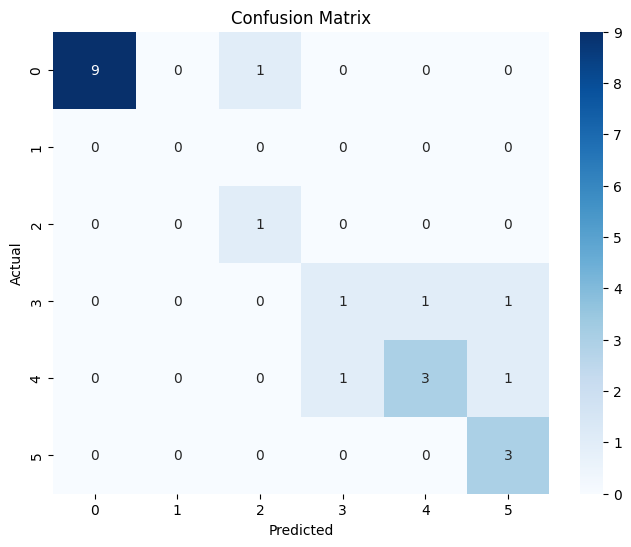


--- Final Test Set Evaluation without 'Week8_Total' ---
Test Accuracy: 0.6364
Test Precision: 0.4200
Test Recall: 0.4333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         3
           4       0.60      0.60      0.60         5
           5       0.50      0.67      0.57         3

    accuracy                           0.64        22
   macro avg       0.42      0.43      0.42        22
weighted avg       0.66      0.64      0.64        22



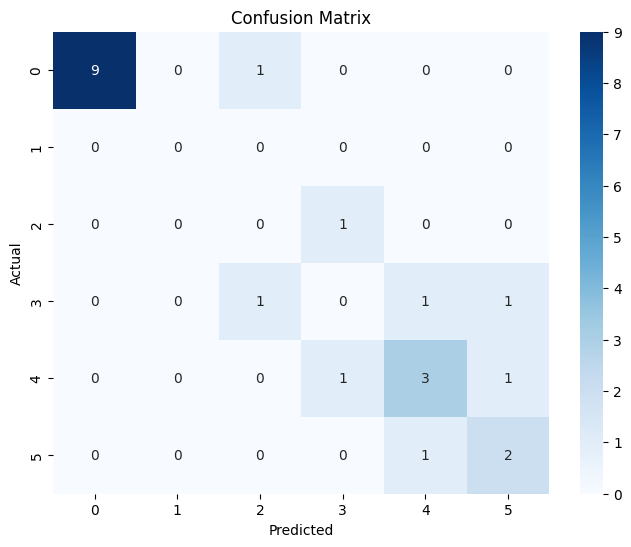

In [ ]:
print("\n--- Final Test Set Evaluation with 'Week8_Total' ---")
final_test_evaluation(best_knn_with, X_test_with_scaled, y_test)

print("\n--- Final Test Set Evaluation without 'Week8_Total' ---")
final_test_evaluation(best_knn_without, X_test_without_scaled, y_test)

#### Which Features are best for KNN

PS: An interesting thing to note here is, Week8_Total doesn't have the highest feature importance.


Feature Importance for KNN with 'Week8_Total':
Top 3 Most Important Features:
        Feature  Importance
5     Week7_MP3    0.131818
9   Week8_Total    0.095455
10  Week3_Stat0    0.095455


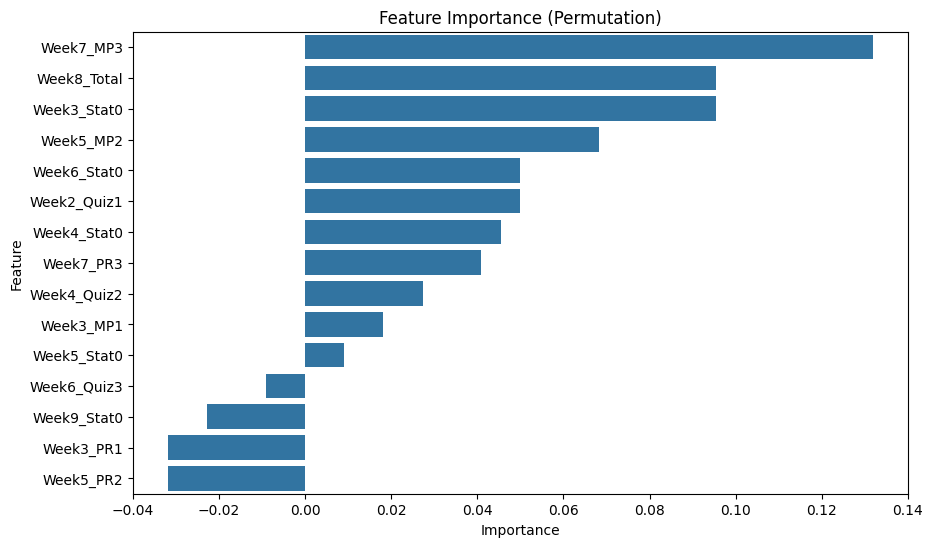


Feature Importance for KNN without 'Week8_Total':
Top 3 Most Important Features:
       Feature  Importance
9  Week3_Stat0    0.077273
3    Week5_MP2    0.059091
5    Week7_MP3    0.036364


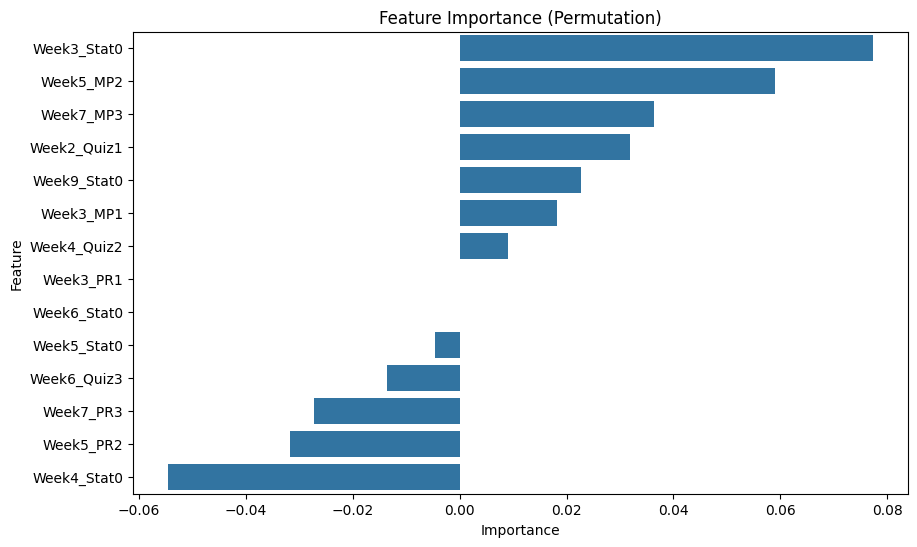

In [ ]:
print("\nFeature Importance for KNN with 'Week8_Total':")
calculate_feature_importance(best_knn_with, X_test_with_scaled, y_test, features_with_week8_total)

print("\nFeature Importance for KNN without 'Week8_Total':")
calculate_feature_importance(best_knn_without, X_test_without_scaled, y_test, features_without_week8_total)

#### Decision Boundries for KNN

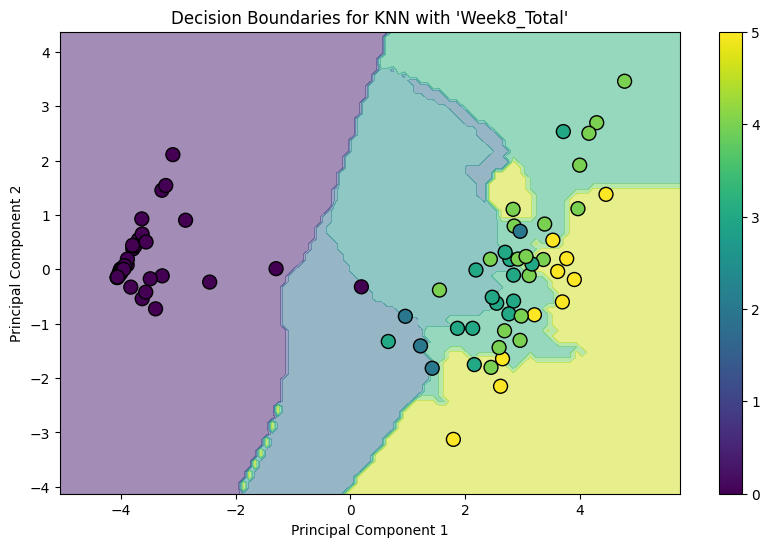

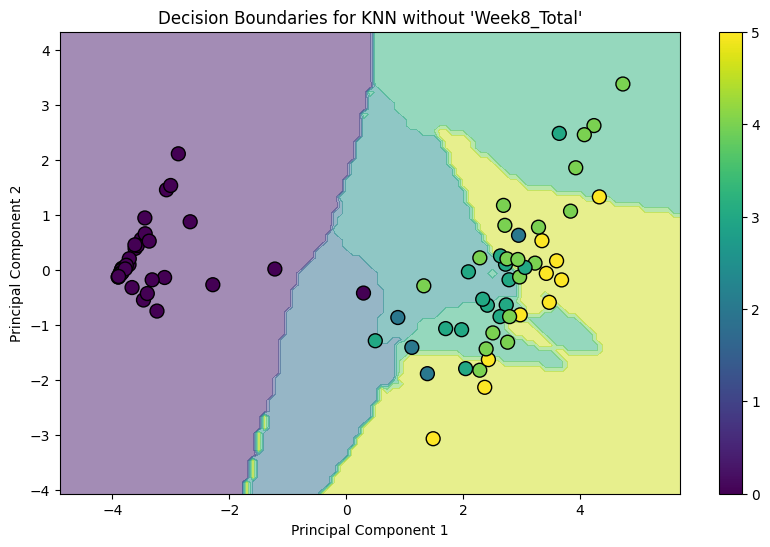

In [ ]:
plot_decision_boundaries(X_train_with_scaled, y_train, best_knn_with, "KNN with 'Week8_Total'")

plot_decision_boundaries(X_train_without_scaled, y_train, best_knn_without, "KNN without 'Week8_Total'")

## Random Forrest
For the Random Forest approach, I used both versions of the feature set—one with the ‘Week8_Total’ feature and one without it—to evaluate the model’s performance. I standardized the features to ensure uniform scaling across all inputs. For hyperparameter tuning, I used Grid Search with 5-fold cross-validation to identify the optimal parameters for Random Forest, such as the number of trees, maximum depth, and minimum samples required for splitting and leaf nodes. Random Forest naturally handles feature importance, which allowed me to identify the most significant features for predicting the target variable.
Evaluation Matrices used here are same as of KNN so that it makes comparison easier.
Since, There were a lot of features involved so for visual representation I first did PCA.

##### Function Definations, used in Random Forrest.

In [ ]:
def final_test_evaluation_rf(model, X_test, y_test):
    test_predictions_rf = model.predict(X_test)
    test_accuracy_rf = accuracy_score(y_test, test_predictions_rf)
    test_precision_rf = precision_score(y_test, test_predictions_rf, average='macro')
    test_recall_rf = recall_score(y_test, test_predictions_rf, average='macro')

    print(f"Test Accuracy: {test_accuracy_rf:.4f}")
    print(f"Test Precision: {test_precision_rf:.4f}")
    print(f"Test Recall: {test_recall_rf:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, test_predictions_rf))

    cm_rf = confusion_matrix(y_test, test_predictions_rf, labels=[0, 1, 2, 3, 4, 5])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3, 4, 5], yticklabels=[0, 1, 2, 3, 4, 5])
    plt.title('Confusion Matrix for Random Forest')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Function to evaluate the classification model using cross-validation for Random Forest
def evaluate_classification_model_rf(model, X_train, y_train):
    stratified_kfold_rf = StratifiedKFold(n_splits=5)
    cv_scores_rf = cross_val_score(model, X_train, y_train, cv=stratified_kfold_rf, scoring='accuracy')
    print(f'Cross-Validation Accuracy Scores: {cv_scores_rf}')
    print(f'Mean Cross-Validation Accuracy: {cv_scores_rf.mean():.4f}')
    return cv_scores_rf.mean()

# Function to calculate and visualize feature importance using Random Forest
def calculate_feature_importance_rf(model, feature_names):
    # Get feature importances from the Random Forest model
    importance_scores_rf = model.feature_importances_

    feature_importance_df_rf = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_scores_rf
    }).sort_values(by='Importance', ascending=False)

    print("Top 3 Most Important Features (Random Forest):")
    print(feature_importance_df_rf.head(3))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf)
    plt.title('Feature Importance (Random Forest)')
    plt.show()

# Function to plot predictions with true labels using shapes and colors
def plot_predictions_shapes(model, X, y, gTitle):
    # Get predictions for the test set
    y_pred = model.predict(X)

    colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'purple', 5: 'cyan'}
    markers = {0: 'o', 1: 's', 2: 'D', 3: '^', 4: 'v', 5: 'X'}

    plt.figure(figsize=(10, 6))

    # Loop through the test data
    for i in range(len(X)):
        true_label = y.iloc[i]
        predicted_label = y_pred[i]

        # Add jitter to the data points, because many points were overlapping.
        jitter_x = np.random.normal(0, 0.02)
        jitter_y = np.random.normal(0, 0.02)

        # Plot each point with the corresponding color and marker
        plt.scatter(X[i, 0] + jitter_x, X[i, 1] + jitter_y,
                    color=colors[true_label],
                    marker=markers[predicted_label],
                    s=50,
                    alpha=0.7)

    for label, color in colors.items():
        plt.scatter([], [], color=color, label=f'True: {label}', marker='o', s=100)

    for label, marker in markers.items():
        plt.scatter([], [], color='black', label=f'Predicted: {label}', marker=marker, s=100)

    plt.title(gTitle)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid()

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
    plt.tight_layout()
    plt.show()

#### Model Training

ps: it may take few minutes for execution (approx 5 minutes)

In [ ]:
# Splitting the data with 'Week8_Total' as a feature for Random Forest
for train_idx, test_idx in stratified_split.split(data[features_with_week8_total], data[target]):
    X_train_with_rf, X_test_with_rf = data[features_with_week8_total].iloc[train_idx], data[features_with_week8_total].iloc[test_idx]
    y_train_rf, y_test_rf = data[target].iloc[train_idx], data[target].iloc[test_idx]

# Splitting the data without 'Week8_Total' for Random Forest
for train_idx, test_idx in stratified_split.split(data[features_without_week8_total], data[target]):
    X_train_without_rf, X_test_without_rf = data[features_without_week8_total].iloc[train_idx], data[features_without_week8_total].iloc[test_idx]
    y_train_rf, y_test_rf = data[target].iloc[train_idx], data[target].iloc[test_idx]

# Standardizing (scaling) the features for Random Forest
scaler_rf = StandardScaler()
X_train_with_rf_scaled = scaler_rf.fit_transform(X_train_with_rf)
X_test_with_rf_scaled = scaler_rf.transform(X_test_with_rf)

X_train_without_rf_scaled = scaler_rf.fit_transform(X_train_without_rf)
X_test_without_rf_scaled = scaler_rf.transform(X_test_without_rf)

# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
}

rf_classifier = RandomForestClassifier(random_state=42)

# Grid search with 'Week8_Total' features for Random Forest
grid_search_rf_with = GridSearchCV(rf_classifier, rf_params, cv=5, scoring='accuracy')
grid_search_rf_with.fit(X_train_with_rf_scaled, y_train_rf)
best_rf_with = grid_search_rf_with.best_estimator_

# Grid search without 'Week8_Total' features for Random Forest
grid_search_rf_without = GridSearchCV(rf_classifier, rf_params, cv=5, scoring='accuracy')
grid_search_rf_without.fit(X_train_without_rf_scaled, y_train_rf)
best_rf_without = grid_search_rf_without.best_estimator_


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


#### Evaluate Random Forrest Using K-Fold

In [ ]:
print("\nBest Random Forest with 'Week8_Total'")
evaluate_classification_model_rf(best_rf_with, X_train_with_rf_scaled, y_train_rf)

print("\nBest Random Forest without 'Week8_Total'")
evaluate_classification_model_rf(best_rf_without, X_train_without_rf_scaled, y_train_rf)




Best Random Forest with 'Week8_Total'


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Cross-Validation Accuracy Scores: [0.94117647 0.94117647 0.88235294 0.88235294 0.94117647]
Mean Cross-Validation Accuracy: 0.9176

Best Random Forest without 'Week8_Total'


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Cross-Validation Accuracy Scores: [0.88235294 0.82352941 0.76470588 0.82352941 0.76470588]
Mean Cross-Validation Accuracy: 0.8118


0.8117647058823529

#### Evaluate Random Forrest Using Hold Out


--- Final Test Set Evaluation with 'Week8_Total' ---
Test Accuracy: 0.9091
Test Precision: 0.7200
Test Recall: 0.7600

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           2       0.00      0.00      0.00         1
           3       0.60      1.00      0.75         3
           4       1.00      0.80      0.89         5
           5       1.00      1.00      1.00         3

    accuracy                           0.91        22
   macro avg       0.72      0.76      0.73        22
weighted avg       0.90      0.91      0.90        22



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

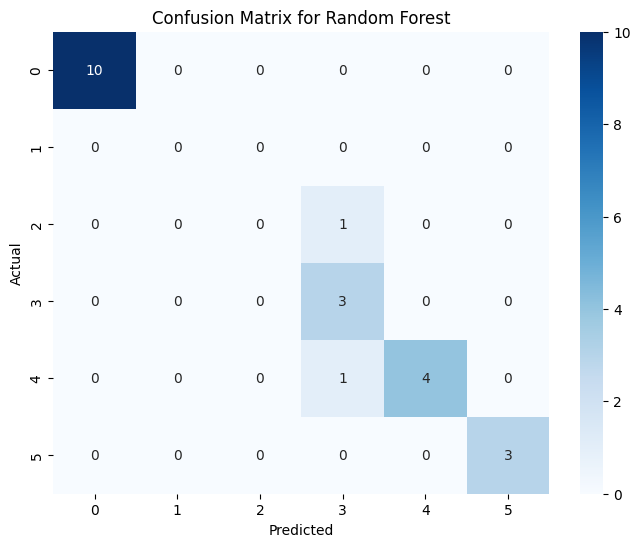


--- Final Test Set Evaluation without 'Week8_Total' ---
Test Accuracy: 0.7273
Test Precision: 0.4333
Test Recall: 0.4933

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         3
           4       0.67      0.80      0.73         5
           5       0.50      0.67      0.57         3

    accuracy                           0.73        22
   macro avg       0.43      0.49      0.46        22
weighted avg       0.67      0.73      0.70        22



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

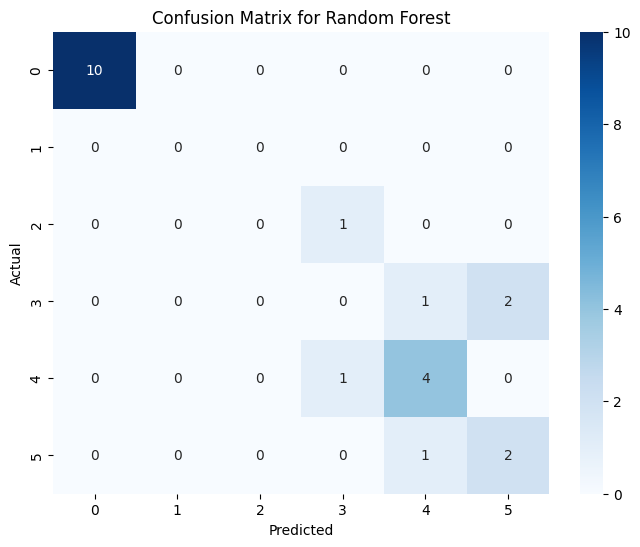

In [ ]:
print("\n--- Final Test Set Evaluation with 'Week8_Total' ---")
final_test_evaluation_rf(best_rf_with, X_test_with_rf_scaled, y_test_rf)

print("\n--- Final Test Set Evaluation without 'Week8_Total' ---")
final_test_evaluation_rf(best_rf_without, X_test_without_rf_scaled, y_test_rf)



#### Top Features for Random Forresr


Feature Importance for Random Forest with 'Week8_Total':
Top 3 Most Important Features (Random Forest):
       Feature  Importance
9  Week8_Total    0.246739
5    Week7_MP3    0.156113
3    Week5_MP2    0.127870


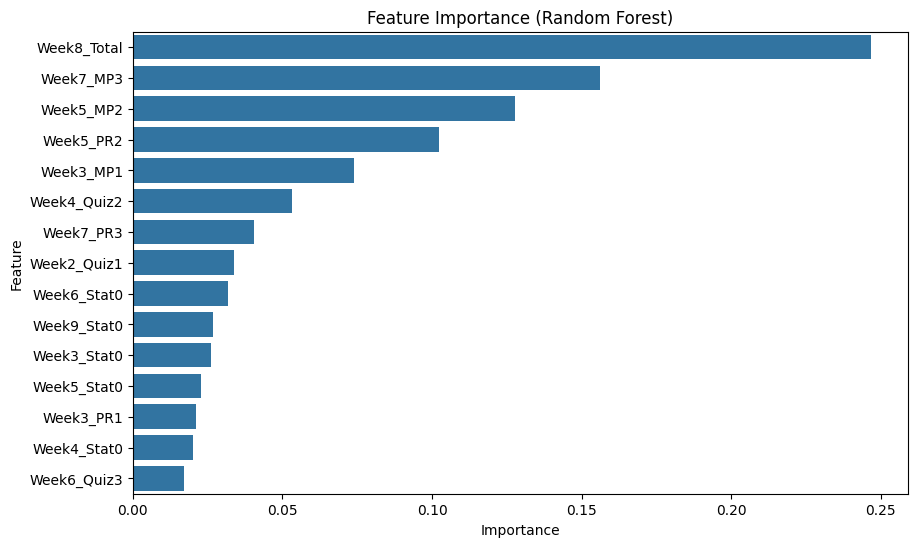


Feature Importance for Random Forest without 'Week8_Total':
Top 3 Most Important Features (Random Forest):
     Feature  Importance
5  Week7_MP3    0.233492
3  Week5_MP2    0.109749
6  Week7_PR3    0.078716


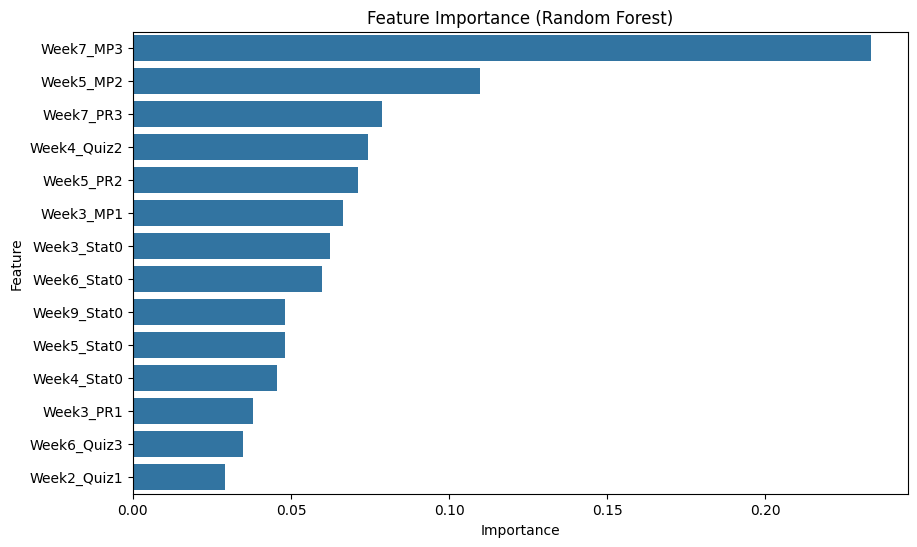

In [ ]:
print("\nFeature Importance for Random Forest with 'Week8_Total':")
calculate_feature_importance_rf(best_rf_with, features_with_week8_total)

print("\nFeature Importance for Random Forest without 'Week8_Total':")
calculate_feature_importance_rf(best_rf_without, features_without_week8_total)

#### Visual Representation for Predictions


--- t-Visualization for Random Forest with 'Week8_Total' ---


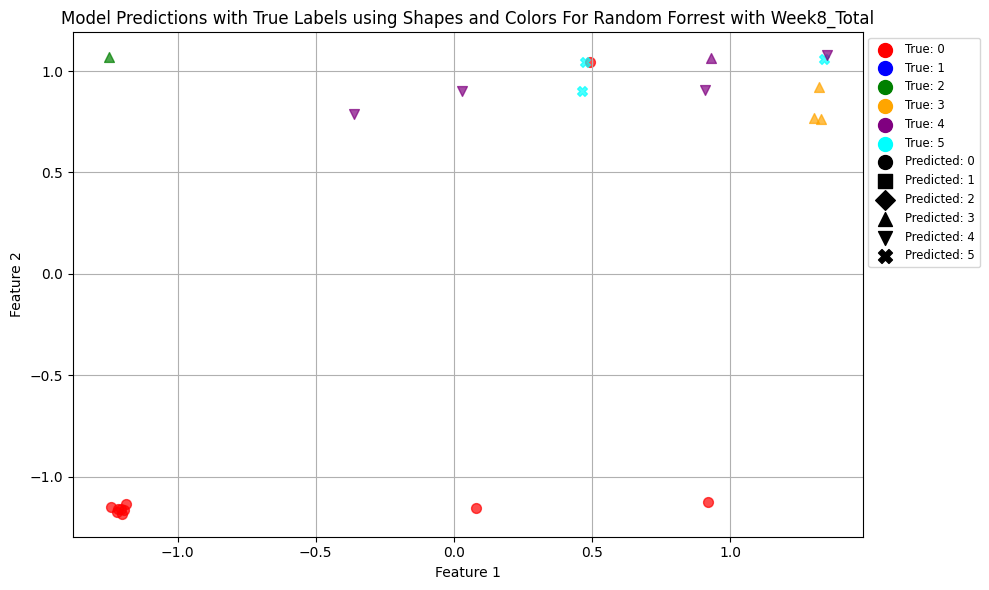


--- t-Visualization for Random Forest without 'Week8_Total' ---


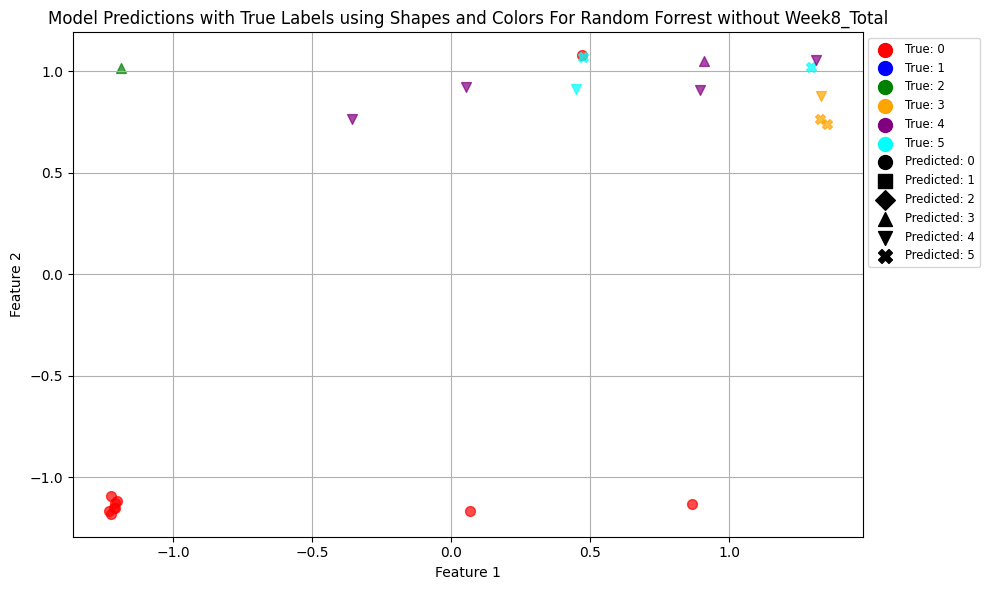

In [ ]:
print("\n--- t-Visualization for Random Forest with 'Week8_Total' ---")
plot_predictions_shapes(best_rf_with, X_test_with_rf_scaled, y_test, "Model Predictions with True Labels using Shapes and Colors For Random Forrest with Week8_Total")

print("\n--- t-Visualization for Random Forest without 'Week8_Total' ---")
plot_predictions_shapes(best_rf_without, X_test_without_rf_scaled, y_test, "Model Predictions with True Labels using Shapes and Colors For Random Forrest without Week8_Total")